<img src="http://meusite.mackenzie.br/rogerio/mackenzie_logo/UPM.2_horizontal_vermelho.jpg"  width=300, align="right">
<br>
<br>
<br>
<br>
<br>

# **Search Algorithms**
---


In [38]:
#@title **Identificação do Grupo**

#@markdown Integrantes do Grupo, nome completo em orgem alfabética (*informe \<RA\>,\<nome\>*)
Aluno1 = '10418358, Bruna Aguiar Muchiuti' #@param {type:"string"}
Aluno2 = '10418247, Gabriel Ken Kazama Geronazzo' #@param {type:"string"}
Aluno3 = '10418013, Lucas Pires de Camargo Sarai' #@param {type:"string"}
Aluno4 = '10410798, Jessica dos Santos Santana Bispo ' #@param {type:"string"}
Aluno5 = '10409053, Otávio Augusto Freire de Andrade Bruzadin' #@param {type:"string"}


In [39]:
%pip install --quiet networkx matplotlib

Note: you may need to restart the kernel to use updated packages.


# **Resumo**

*Apresente um parágrafo resumindo o que é feito neste trabalho*.

# **Implementação**

*Aqui o código da sua solução. Você deve explicar em linhas gerais o código. Para isso você pode quebrar o código em algumas partes e incluir células de texto explicativos. Não empregue para isso comentários no corpo do código, mas crie células de texto do notebook.*

> ***ATENÇÃO: O código deve ser 100% executável no Colab e, portanto, não devem ser empregados arquivos locais (da sua máquina) e, se necessário, devem ser incluídos o install de novas bibliotecas empregadas.***



## **1. Grafo das cidades (2,0)**

In [40]:
import networkx as nx
import matplotlib.pyplot as plt
from itertools import islice

cities_coords = {
    "Sao Paulo": (-23.5505, -46.6333),
    "Rio de Janeiro": (-22.9068, -43.1729),
    "Campinas": (-22.9056, -47.0608),
    "Santos": (-23.9608, -46.3336),
    "Ubatuba": (-23.433, -45.083),
    "Paraty": (-23.217, -44.713),
    "Angra dos Reis": (-23.006, -44.318),
    "Petropolis": (-22.505, -43.178),
    "Belo Horizonte": (-19.9167, -43.9345),
    "Ouro Preto": (-20.385, -43.503),
    "Vitoria": (-20.3155, -40.3128),
    "Curitiba": (-25.4284, -49.2733),
    "Paranagua": (-25.5205, -48.5095),
    "Joinville": (-26.3045, -48.8487),
    "Florianopolis": (-27.5949, -48.5482),
    "Blumenau": (-26.9194, -49.0661),
    "Foz do Iguacu": (-25.5469, -54.5882),
    "Porto Alegre": (-30.0346, -51.2177),
    "Gramado": (-29.373, -50.876),
    "Brasilia": (-15.7939, -47.8828),
    "Goiania": (-16.6869, -49.2648),
    "Salvador": (-12.9777, -38.5016),
    "Porto Seguro": (-16.444, -39.064),
    "Ilheus": (-14.793, -39.047),
    "Recife": (-8.0476, -34.877),
}

roads_km = [
    ("Sao Paulo", "Campinas", 99),
    ("Sao Paulo", "Santos", 80),
    ("Sao Paulo", "Ubatuba", 226),
    ("Sao Paulo", "Curitiba", 408),
    ("Sao Paulo", "Rio de Janeiro", 430),
    ("Campinas", "Belo Horizonte", 586),
    ("Campinas", "Sao Paulo", 99),
    ("Santos", "Ubatuba", 170),
    ("Ubatuba", "Paraty", 73),
    ("Paraty", "Angra dos Reis", 96),
    ("Angra dos Reis", "Rio de Janeiro", 157),
    ("Rio de Janeiro", "Petropolis", 68),
    ("Petropolis", "Belo Horizonte", 440),
    ("Belo Horizonte", "Ouro Preto", 97),
    ("Belo Horizonte", "Vitoria", 524),
    ("Rio de Janeiro", "Vitoria", 521),
    ("Curitiba", "Paranagua", 91),
    ("Curitiba", "Joinville", 132),
    ("Joinville", "Florianopolis", 177),
    ("Joinville", "Blumenau", 74),
    ("Blumenau", "Florianopolis", 150),
    ("Curitiba", "Florianopolis", 300),
    ("Curitiba", "Foz do Iguacu", 643),
    ("Florianopolis", "Porto Alegre", 476),
    ("Porto Alegre", "Gramado", 115),
    ("Sao Paulo", "Brasilia", 1015),
    ("Brasilia", "Goiania", 209),
    ("Brasilia", "Belo Horizonte", 740),
    ("Brasilia", "Salvador", 1440),
    ("Salvador", "Ilheus", 310),
    ("Ilheus", "Porto Seguro", 308),
    ("Salvador", "Recife", 805),
    ("Vitoria", "Porto Seguro", 590),
    ("Goiania", "Belo Horizonte", 906),
    ("Rio de Janeiro", "Sao Paulo", 430),
    ("Santos", "Rio de Janeiro", 500),
    ("Sao Paulo", "Paraty", 270),
    ("Sao Paulo", "Angra dos Reis", 385),
    ("Campinas", "Rio de Janeiro", 510),
    ("Campinas", "Curitiba", 460),
]

In [41]:
# Construção do grafo (nós com posição e arestas com peso em km)
G = nx.Graph()
for city, (lat, lon) in cities_coords.items():
    G.add_node(city, pos=(lon, lat))

for c1, c2, km in roads_km:
    G.add_edge(c1, c2, weight=km)

print(f"Numero de cidades (nos): {G.number_of_nodes()}")
print(f"Numero de conexoes (arestas): {G.number_of_edges()}")

Numero de cidades (nos): 25
Numero de conexoes (arestas): 38


In [42]:
# Cálculo de caminhos alternativos entre São Paulo e Rio de Janeiro
origem, destino = "Sao Paulo", "Rio de Janeiro"
alternativas = list(islice(nx.shortest_simple_paths(G, origem, destino, weight="weight"), 6))

def path_cost(graph, path):
    return sum(graph[path[i]][path[i + 1]]["weight"] for i in range(len(path) - 1))

print("\n6 caminhos alternativos entre Sao Paulo e Rio de Janeiro:")
for i, p in enumerate(alternativas, start=1):
    print(f"{i}. {' -> '.join(p)} | custo = {path_cost(G, p)} km")


6 caminhos alternativos entre Sao Paulo e Rio de Janeiro:
1. Sao Paulo -> Rio de Janeiro | custo = 430 km
2. Sao Paulo -> Paraty -> Angra dos Reis -> Rio de Janeiro | custo = 523 km
3. Sao Paulo -> Angra dos Reis -> Rio de Janeiro | custo = 542 km
4. Sao Paulo -> Ubatuba -> Paraty -> Angra dos Reis -> Rio de Janeiro | custo = 552 km
5. Sao Paulo -> Santos -> Ubatuba -> Paraty -> Angra dos Reis -> Rio de Janeiro | custo = 576 km
6. Sao Paulo -> Santos -> Rio de Janeiro | custo = 580 km


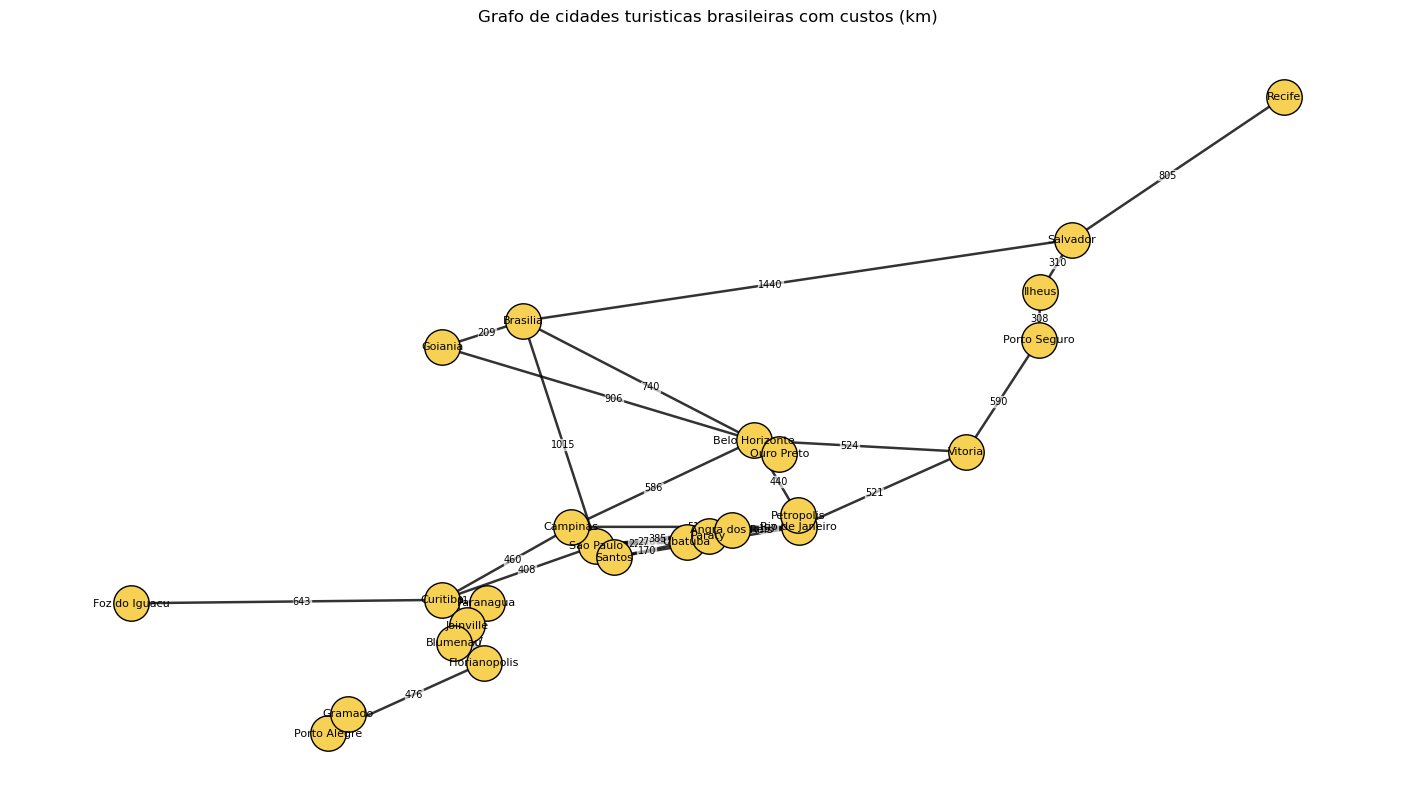

In [43]:
pos = nx.get_node_attributes(G, "pos")

plt.figure(figsize=(18, 10))
nx.draw_networkx_nodes(G, pos, node_color="#f7d154", node_size=650, edgecolors="black")
nx.draw_networkx_edges(G, pos, width=1.8, alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=8)
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=nx.get_edge_attributes(G, "weight"),
    font_size=7,
    rotate=False,
    label_pos=0.55,
    bbox={"alpha": 0.6, "color": "white", "pad": 0.1},
)
plt.title("Grafo de cidades turisticas brasileiras com custos (km)")
plt.axis("off")
plt.show()

> ## **1.1. Resultados (Testes)**

*Um ou mais testes da solução devem ser apresentados ao final. Comente em células de texto explicativas os testes e os seus resultados.*

In [44]:
# Testes de validacao dos requisitos da secao 1.
assert G.number_of_nodes() >= 24, "O grafo precisa ter pelo menos 24 cidades."
assert len(alternativas) >= 6, "Devem existir pelo menos 6 caminhos alternativos."

print("Requisito 1: OK - grafo com no minimo 24 cidades.")
print("Requisito 2: OK - no minimo 6 caminhos alternativos entre Sao Paulo e Rio de Janeiro.")
print(f"Caminho de menor custo encontrado: {' -> '.join(alternativas[0])}")
print(f"Custo do melhor caminho: {path_cost(G, alternativas[0])} km")

Requisito 1: OK - grafo com no minimo 24 cidades.
Requisito 2: OK - no minimo 6 caminhos alternativos entre Sao Paulo e Rio de Janeiro.
Caminho de menor custo encontrado: Sao Paulo -> Rio de Janeiro
Custo do melhor caminho: 430 km


## **2. BFS, Breadth-First Search(2,0)**

In [45]:
# Seus Códigos aqui intercalados de células de texto com comentários

In [46]:
from collections import deque

In [47]:

def bfs(graph, start, goal):
    """
    Breadth-First Search em um grafo não balanceado
    -> Retorna o caminho (lista de nodes) de start a goal,
    ou None se nenhum caminho existir.
    """
    if start == goal:
        return [start]

    visited = {start}

    queue = deque([(start, [start])])

    while queue:
        node, path = queue.popleft()

        for neighbor in graph.neighbors(node):
            if neighbor not in visited:
                new_path = path + [neighbor]
                if neighbor == goal:
                    return new_path
                visited.add(neighbor)
                queue.append((neighbor, new_path))

    return None #nenhum caminho encontrado

In [48]:
origem, destino = "Sao Paulo", "Rio de Janeiro"

bfs_path = bfs(G, origem, destino)

if bfs_path:
    custo = path_cost(G, bfs_path)
    print(f"BFS - Caminho (menor numero de saltos) de {origem} a {destino}:")
    print(" -> ".join(bfs_path))
    print(f"Numero de saltos: {len(bfs_path) - 1}")
    print(f"Custo total (km): {custo}")
else:
    print("nenhum caminho encontrado")

BFS - Caminho (menor numero de saltos) de Sao Paulo a Rio de Janeiro:
Sao Paulo -> Rio de Janeiro
Numero de saltos: 1
Custo total (km): 430


> ## **2.1. Resultados (Testes)**

*Um ou mais testes da solução devem ser apresentados ao final. Comente em células de texto explicativas os testes e os seus resultados.*

In [49]:
# Seus Códigos aqui intercalados de células de texto com comentários

### Testes BFS

In [50]:


# 1. Caminho deve existir
assert bfs_path is not None, "BFS deve encontrar um caminho entre as cidades."

# 2. Primeiro e ultimo nó devem ser corretos
assert bfs_path[0] == origem,  "O caminho deve iniciar na origem."
assert bfs_path[-1] == destino, "O caminho deve terminar no destino."

# 3. Todas as arestas do caminho devem existir no grafo
for i in range(len(bfs_path) - 1):
    assert G.has_edge(bfs_path[i], bfs_path[i+1]), \
        f"Aresta ausente: {bfs_path[i]} -> {bfs_path[i+1]}"

# 4. BFS deve retornar o caminho de menor número de saltos (1 salto)
assert len(bfs_path) - 1 == 1, \
    "Existe aresta direta SP→RJ, então BFS deve retornar caminho de 1 salto."

print("Teste 1: OK - caminho encontrado.")
print("Teste 2: OK - origem e destino corretos.")
print("Teste 3: OK - todas as arestas do caminho existem no grafo.")
print("Teste 4: OK - BFS retornou o caminho de menor numero de saltos (1 salto).")

Teste 1: OK - caminho encontrado.
Teste 2: OK - origem e destino corretos.
Teste 3: OK - todas as arestas do caminho existem no grafo.
Teste 4: OK - BFS retornou o caminho de menor numero de saltos (1 salto).


## **3. Busca Informada (5,0)**

*Indique aqui em um texto o algoritmo de Busca Informada escolhido e o motivo da escolha.*

In [51]:
# Seus Códigos aqui intercalados de células de texto com comentários

> ## **3.1. Resultados (Testes)**

*Um ou mais testes da solução devem ser apresentados ao final. Comente em células de texto explicativas os testes e os seus resultados.*

In [52]:
# Seus Códigos aqui intercalados de células de texto com comentários

# **Referências**

Este é um item obrigatório. Inclua aqui o as referências, fontes, ou bibliografia e sites/bibliotecas empregadas em formato ABNT.

---

FEOFILOFF, Paulo. Busca em largura (BFS). Instituto de Matemática e Estatística, Universidade de São Paulo, [s.d.]. Disponível em: https://www.ime.usp.br/~pf/algoritmos_para_grafos/aulas/bfs.html. Acesso em: 17 mar. 2026.

In [58]:
#@title **Avaliação**
Resumo = 10 #@param {type:"slider", min:0, max:10, step:1}

Grafo = 9 #@param {type:"slider", min:0, max:10, step:1}

BFS = 6 #@param {type:"slider", min:0, max:10, step:1}

Busca_Informada = 8 #@param {type:"slider", min:0, max:10, step:1}

Referencias = 7 #@param {type:"slider", min:0, max:10, step:1}

Geral = 7 #@param {type:"slider", min:0, max:10, step:1}








In [59]:
#@title **Nota Final**

nota = Resumo + 2*Grafo + 3*BFS + 5*Busca_Informada + Referencias + Geral

nota = nota / 13

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_tia = []
lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_tia.append(lista[0]); lista_nome.append(lista[1].upper())")

alunos['tia'] = lista_tia
alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota final do trabalho 7.7



,tia,nome,nota
0,10418358,BRUNA AGUIAR MUCHIUTI,7.7
1,10418247,GABRIEL KEN KAZAMA GERONAZZO,7.7
2,10418013,LUCAS PIRES DE CAMARGO SARAI,7.7
3,10410798,JESSICA DOS SANTOS SANTANA BISPO,7.7
4,10409053,OTÁVIO AUGUSTO FREIRE DE ANDRADE BRUZADIN,7.7
